# Configuración script

## Dependencias

In [1]:
#Importar dependencias
from psm.em_mod import choose_data, em_array
from psm.sim_mod import sim
from psm.graph import plt_sim,get_d_plt,matrix_plt,interval_95,matrix_sel
from psm.mle_mod import mle_
from psm.qua_mod import qua_var

import numpy as np
from numpy.random import default_rng

import pandas as pd

import matplotlib.pyplot as plt
plt.ioff()  # Desactiva el modo interactivo

## Parametros
Cada mode lo requiere los siguientes parametros:
- param
- sigma
- time
- n_iter
- start
- l_inf

En caso de realizar la simulación con el modelo EM se requiere
- n_obs

In [2]:
#Variables globales
#Lista con tipos de modelo
ls_type = ['g','l','v']
#Parametro que se quiere estimar
param = 0.6
#Sigma
sigma = 0.001
#Tiempo considerado en el proceso estocasico
time = 10
#Numero de iteraciones
n_iter = 10000
#Delta tamaño de los pasos o intervalos
delta = time/n_iter
delta = 0.001
#Sumamos 1 para considerar el valor inicial
n_iter += 1
#Valor inicial de la simulación
start = 0.01
#Limite superior
l_inf = 9999999999.0
#_____________________________________________
#Variables modelo em
#Número tamaño de pasos para la muestra
n_obs = 100
#_____________________________________________
#Número de ejecuciones del modelo para los intervalos de confianza
n_reply = 1000 
#_____________________________________________
#Fijamos semilla aleatoria
seed = 1000
rng = default_rng(seed=seed)
#_____________________________________________
d_result = {}

# Trayectorias y estimadores
Para ilustrar la consistencia de los estimadores del modelo de cada modelo,  generamos trayectorias con
diferentes horizontes temporales. De hecho, generamos una trayectoria en el intervalo de tiempo [0, ***time***] con una
discretización de ***time/n_iter*** y ***n_iter*** valores. 

Calculamos los estimadores en cada observación. La trayectoria se generó con:
- x0 = ***start***
- parametro = ***param*** (beta en caso Gompertz, r en caso Logistic, kappa en caso Von Bert) 
- σ = ***sigma***. 

En las siguientes figuras se representa la trayectoria, la grafica y la grafica de los estimadores que se obtuvieron utilizando horizontes temporales [0, tk] para tk = ∆nk

Donde los siguientes valores vienen de los parametros globales:
- ***time***
- ***n_iter***
- ***start***
- ***param***
- ***sigma***

## Gompertz

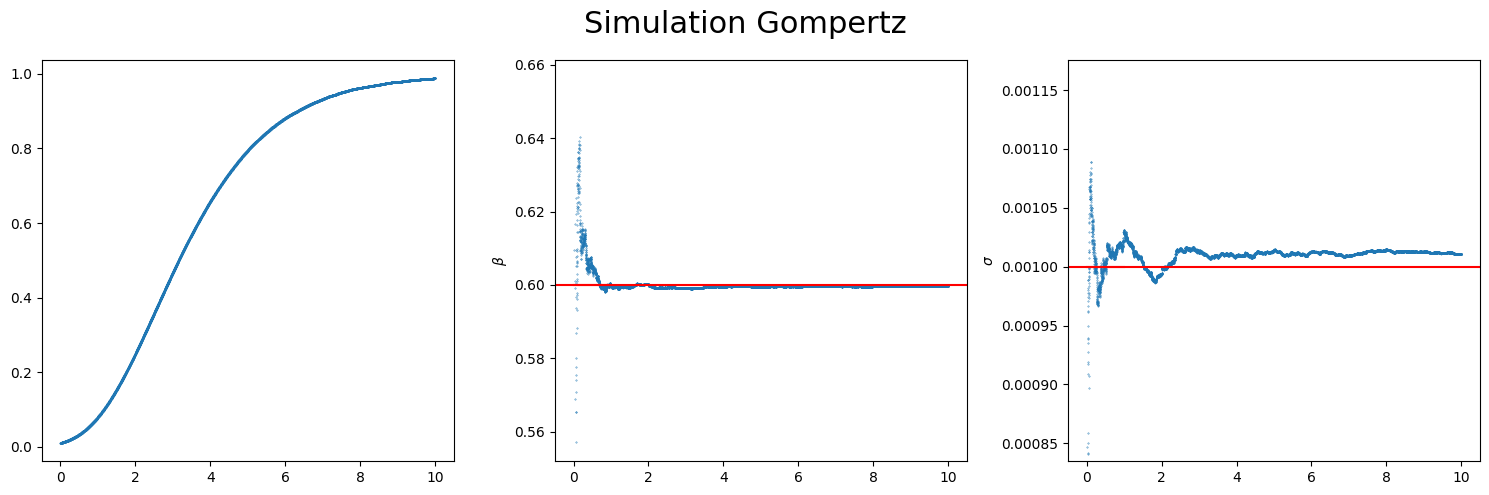

In [3]:
type_model = 'g'
array = sim(type_model,param,sigma,delta,start,n_iter)
axes_list = []
d_for = {}
for type_graph in ['n','mle','qua']:
    if type_graph == 'mle':
        y_val = param
        zoom = True
        d_for['mle_sim'] = float(mle_(type_model,array,delta,l_inf))
    elif type_graph == 'qua':
        y_val = sigma
        zoom = True
        d_for['qua_sim'] = float(qua_var(type_model,array,delta,l_inf))
    else:
        y_val = None
        zoom = False
        d_for['real'] = param
        d_for['sigma'] = sigma
    d_plt = get_d_plt(type_model,array,delta,type_graph,y_val,l_inf=9999999999.0)
    f_f,ax = plt_sim(**d_plt, zoom=zoom)
    axes_list = axes_list + [ax]
    plt.close(f_f)
d_result[type_model] = d_for

fig_final, axes = matrix_plt(axes_list)
fig_final.suptitle(d_plt['title'], fontsize=22)
# Ajustar el diseño
plt.tight_layout()
plt.show()

## Logistic

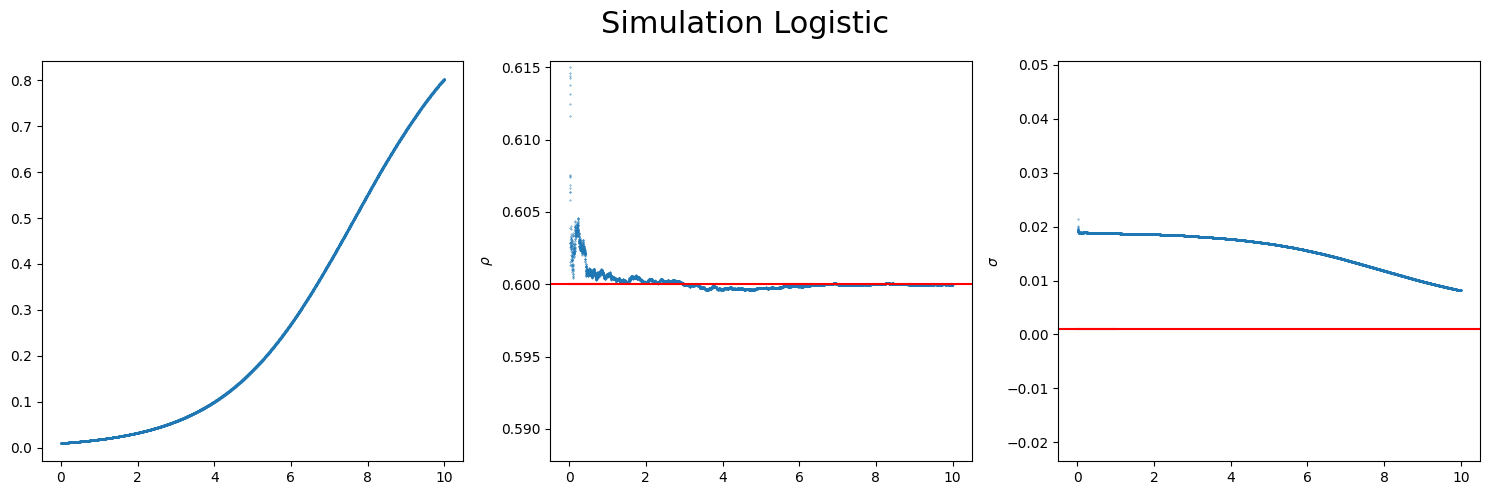

In [4]:
type_model = 'l'
array = sim(type_model,param,sigma,delta,start,n_iter)
axes_list = []
d_for = {}
for type_graph in ['n','mle','qua']:
    if type_graph == 'mle':
        y_val = param
        zoom = True
        d_for['mle_sim'] = float(mle_(type_model,array,delta,l_inf))
    elif type_graph == 'qua':
        y_val = sigma
        zoom = True
        d_for['qua_sim'] = float(qua_var(type_model,array,delta,l_inf))
    else:
        y_val = None
        zoom = False
        d_for['real'] = param
        d_for['sigma'] = sigma
    d_plt = get_d_plt(type_model,array,delta,type_graph,y_val,l_inf=9999999999.0)
    f_f,ax = plt_sim(**d_plt, zoom=zoom)
    axes_list = axes_list + [ax]
    plt.close(f_f)
d_result[type_model] = d_for

fig_final, axes = matrix_plt(axes_list)
fig_final.suptitle(d_plt['title'], fontsize=22)
# Ajustar el diseño
plt.tight_layout()
plt.show()

## Von Bert

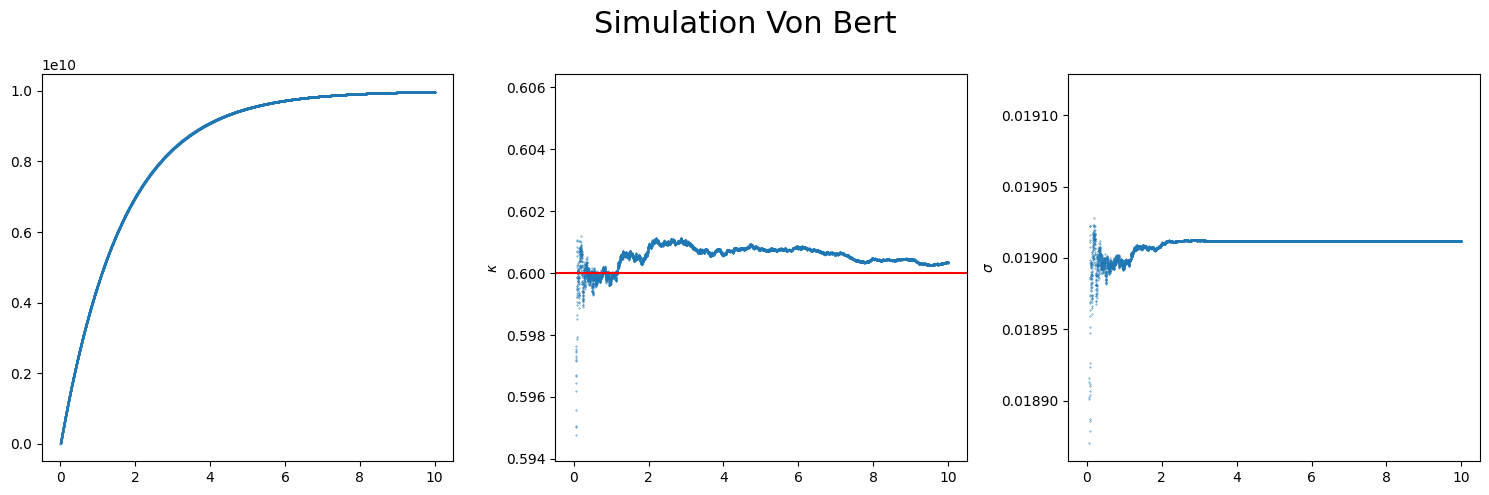

In [5]:
type_model = 'v'
array = sim(type_model,param,sigma,delta,start,n_iter)
axes_list = []
d_for = {}
for type_graph in ['n','mle','qua']:
    if type_graph == 'mle':
        y_val = param
        zoom = True
        d_for['mle_sim'] = float(mle_(type_model,array,delta,l_inf))
    elif type_graph == 'qua':
        y_val = sigma
        zoom = True
        d_for['qua_sim'] = float(qua_var(type_model,array,delta,l_inf))
    else:
        y_val = None
        zoom = False
        d_for['real'] = param
        d_for['sigma'] = sigma
    d_plt = get_d_plt(type_model,array,delta,type_graph,y_val,l_inf)
    f_f,ax = plt_sim(**d_plt, zoom=zoom)
    axes_list = axes_list + [ax]
    plt.close(f_f)
d_result[type_model] = d_for

fig_final, axes = matrix_plt(axes_list)
fig_final.suptitle(d_plt['title'], fontsize=22)
# Ajustar el diseño
plt.tight_layout()
plt.show()

# Información incompleta
En esta subsección, presentamos la validación de nuestros métodos asumiendo una observación discreta para
los tres modelos. El conjunto de datos
se generó simulando una ruta de muestra de ***n_iter** puntos en el intervalo de tiempo [0,***time***],
comenzando en x0 = ***start***. Suponemos que hemos observado solo ***n_obs*** los cuales se toman de forma homogenea cada mayor entero de ***n_obs/n_inter***

A partir de esta extracción se generaran trayectorias de tamaño ***n_obs*** para acompletar la trayectoria y graficaremos los estimadores

## Gompertz

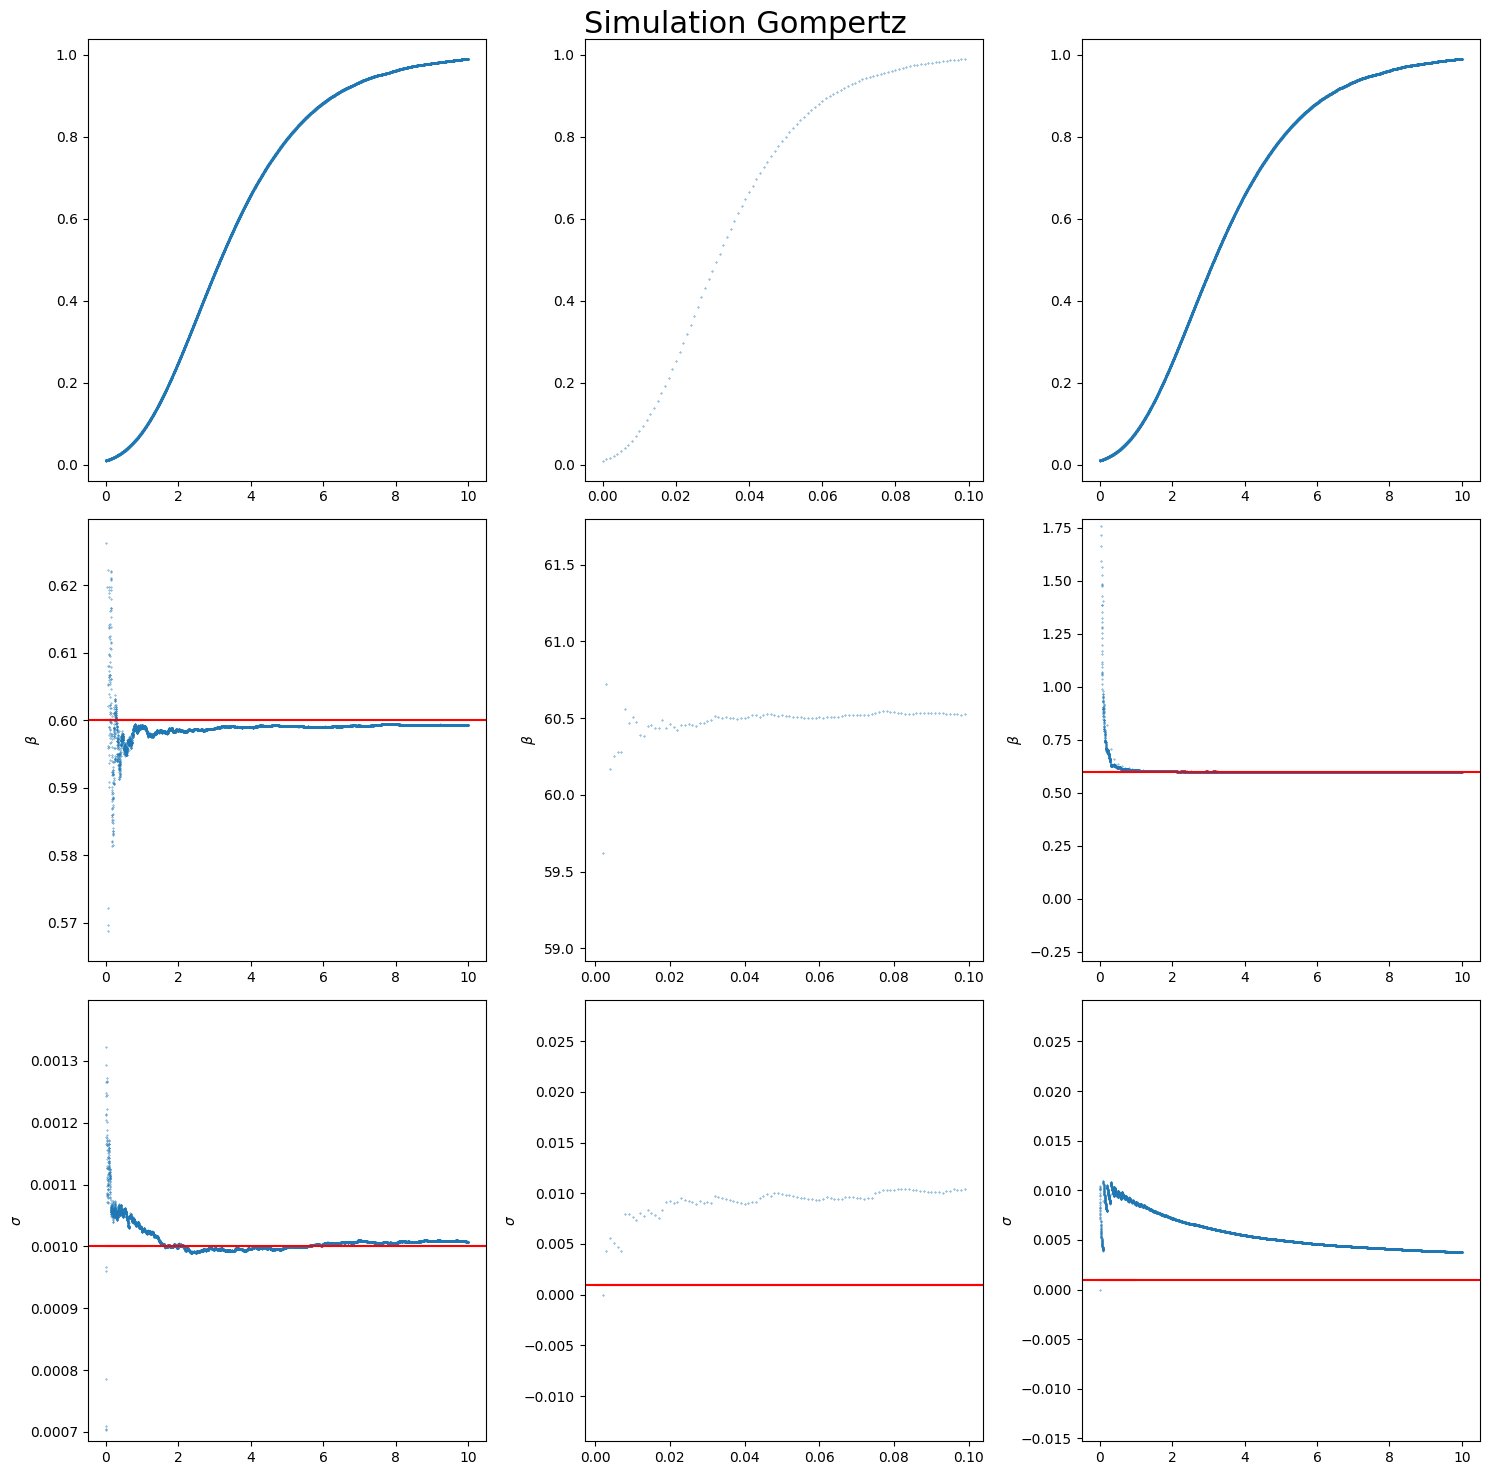

In [6]:
type_model = 'g'
axes_list = []
d_for = {}
n_iter_choose = n_iter//n_obs
array = sim(type_model,param,sigma,delta,start,n_iter,l_inf)
array_choose = choose_data(array,n_obs)
array_final = em_array(type_model,array_choose,param,sigma,delta,n_iter_choose,n_obs,l_inf)
array_final = array_final.flatten()
ls_array = [array,array_choose,array_final]

for type_graph in ['n','mle','qua']:
    if type_graph == 'mle':
        y_val = param
        zoom = True
        d_for['mle_em'] = float(mle_(type_model,array_final,delta,l_inf))
    elif type_graph == 'qua':
        y_val = sigma
        zoom = True
        d_for['qua_em'] = float(qua_var(type_model,array_final,delta,l_inf))
    else:
        y_val = None
        zoom = False
    for arr in ls_array:
        d_plt = get_d_plt(type_model,arr,delta,type_graph,y_val,l_inf)
        f_f,ax =plt_sim(**d_plt, zoom=zoom)
        plt.close(f_f)
        axes_list = axes_list + [ax]
d_result[type_model] = d_result[type_model] | d_for

fig_final, axes = matrix_plt(axes_list,3)
fig_final.suptitle(d_plt['title'], fontsize=22)
# Ajustar el diseño
plt.tight_layout()
plt.show()

## Logistic

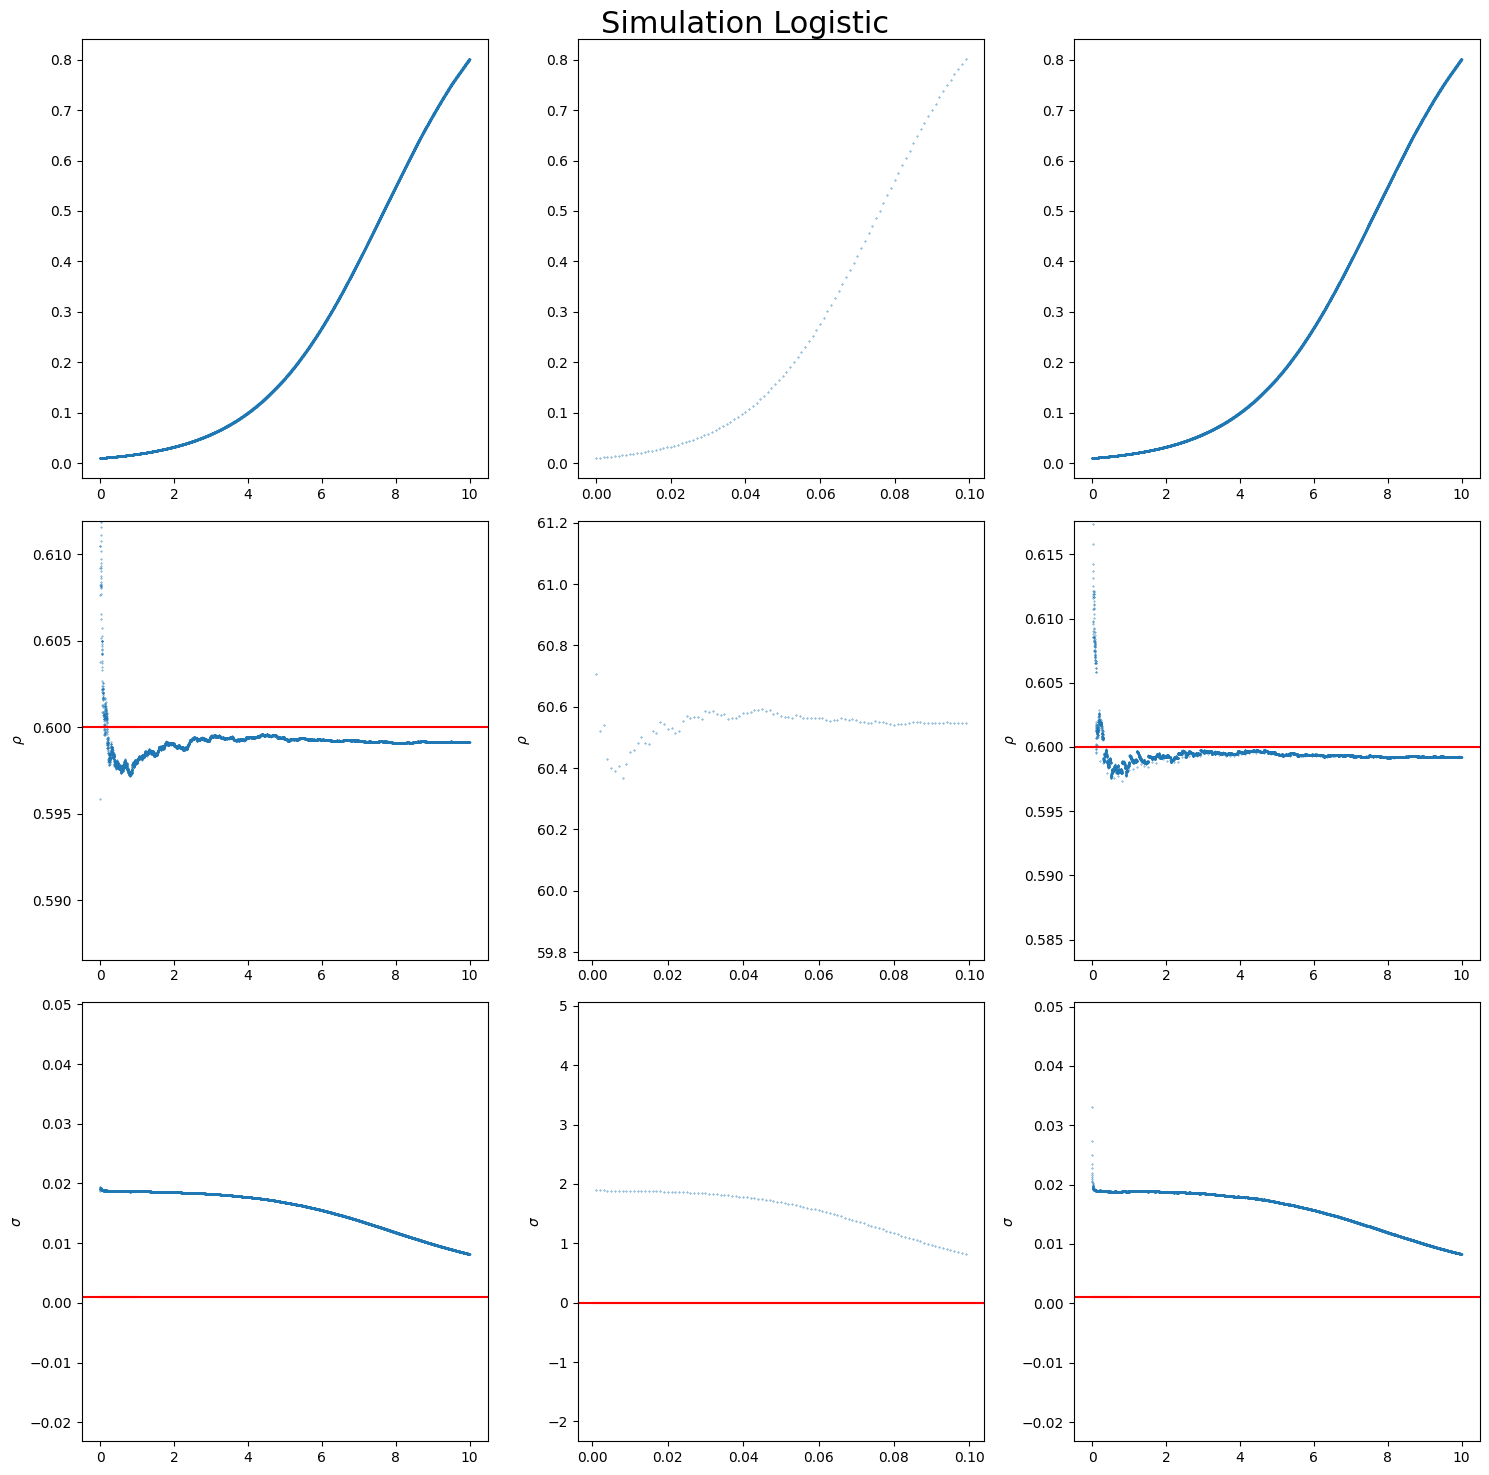

In [7]:
type_model = 'l'
axes_list = []
d_for = {}
n_iter_choose = n_iter//n_obs
array = sim(type_model,param,sigma,delta,start,n_iter,l_inf)
array_choose = choose_data(array,n_obs)
array_final = em_array(type_model,array_choose,param,sigma,delta,n_iter_choose,n_obs,l_inf)
array_final = array_final.flatten()
ls_array = [array,array_choose,array_final]

for type_graph in ['n','mle','qua']:
    if type_graph == 'mle':
        y_val = param
        zoom = True
        d_for['mle_em'] = float(mle_(type_model,array_final,delta,l_inf))
    elif type_graph == 'qua':
        y_val = sigma
        zoom = True
        d_for['qua_em'] = float(qua_var(type_model,array_final,delta,l_inf))
    else:
        y_val = None
        zoom = False
    for arr in ls_array:
        d_plt = get_d_plt(type_model,arr,delta,type_graph,y_val,l_inf)
        f_f,ax =plt_sim(**d_plt, zoom=zoom)
        plt.close(f_f)
        axes_list = axes_list + [ax]
d_result[type_model] = d_result[type_model] | d_for

fig_final, axes = matrix_plt(axes_list,3)
fig_final.suptitle(d_plt['title'], fontsize=22)
# Ajustar el diseño
plt.tight_layout()
plt.show()

## Von Bert

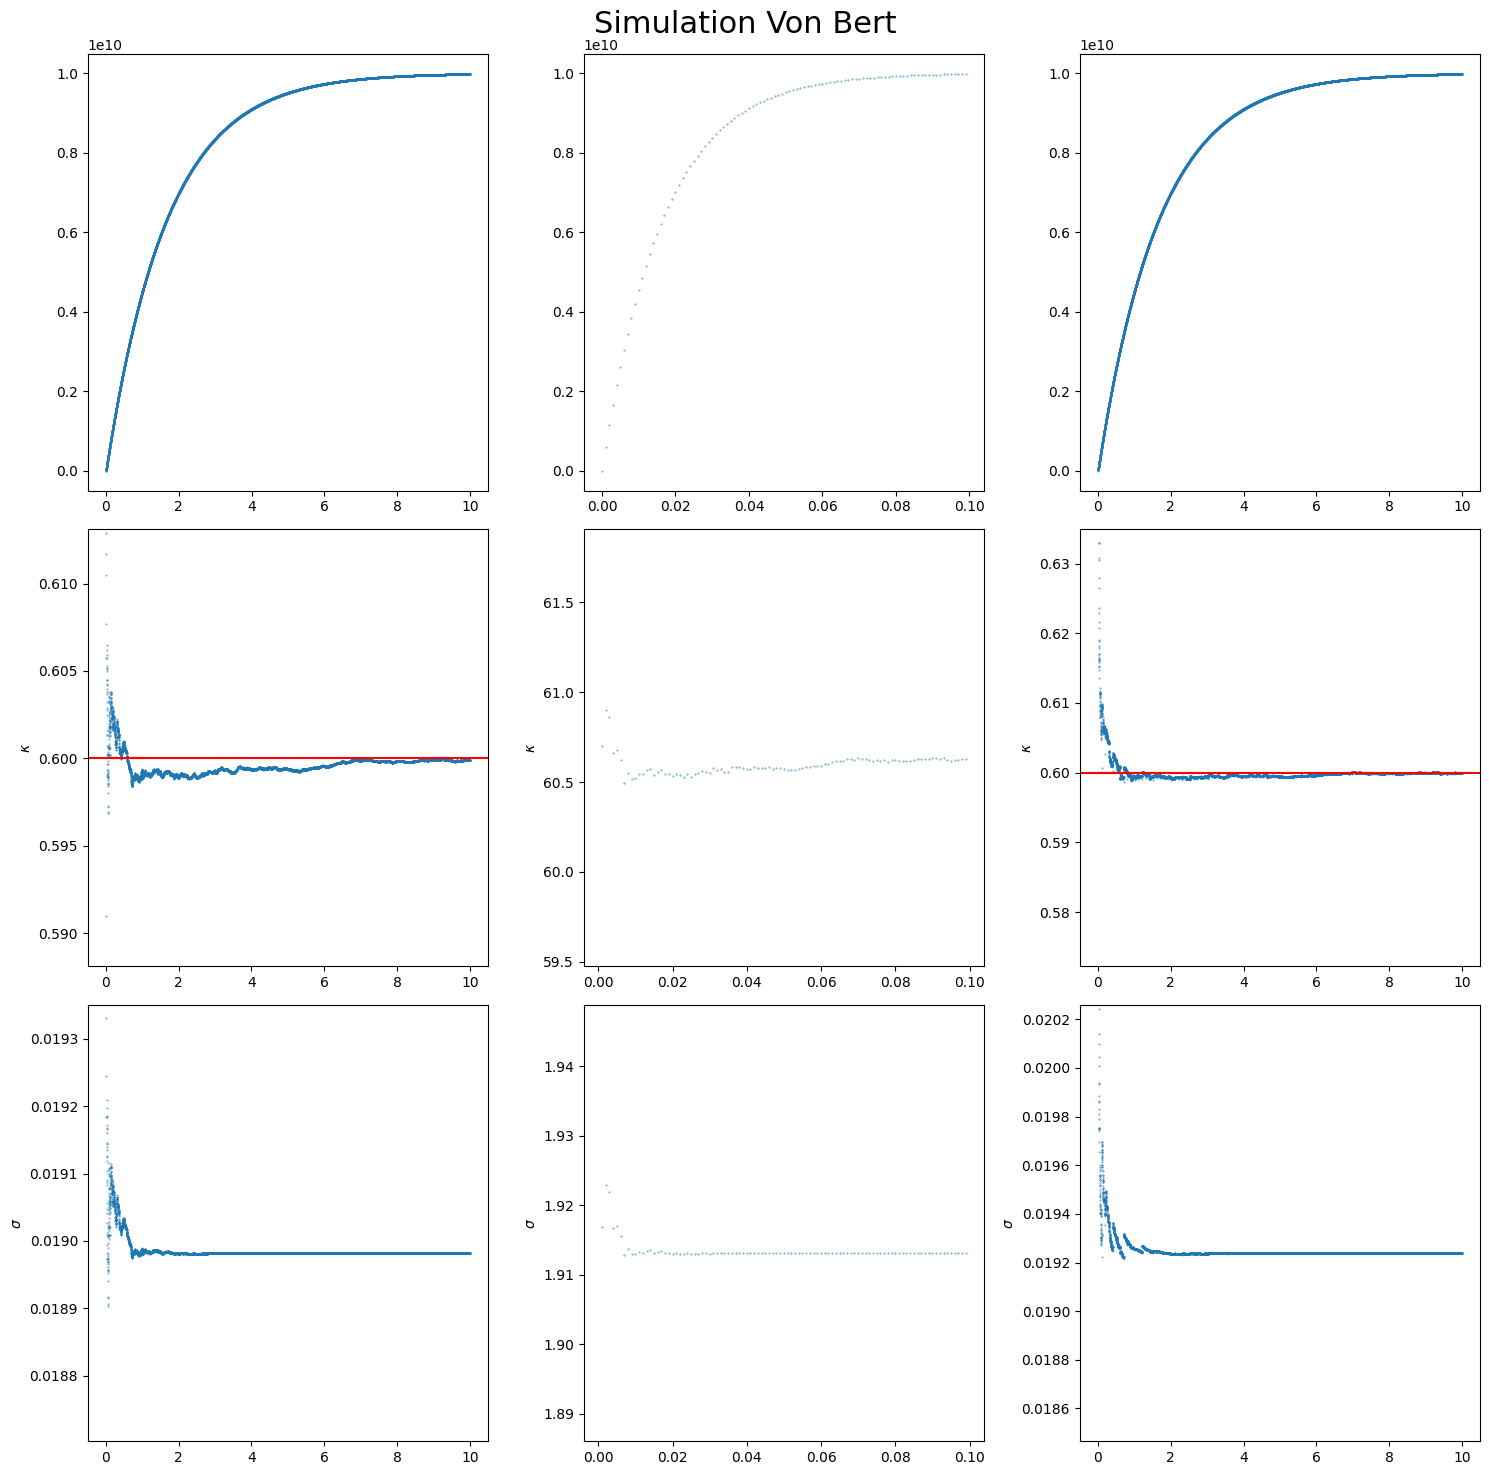

In [8]:
type_model = 'v'
axes_list = []
d_for = {}
n_iter_choose = n_iter//n_obs
array = sim(type_model,param,sigma,delta,start,n_iter,l_inf)
array_choose = choose_data(array,n_obs)
array_final = em_array(type_model,array_choose,param,sigma,delta,n_iter_choose,n_obs,l_inf)
array_final = array_final.flatten()
ls_array = [array,array_choose,array_final]

for type_graph in ['n','mle','qua']:
    if type_graph == 'mle':
        y_val = param
        zoom = True
        d_for['mle_em'] = float(mle_(type_model,array_final,delta,l_inf))
    elif type_graph == 'qua':
        y_val = sigma
        zoom = True
        d_for['qua_em'] = float(qua_var(type_model,array_final,delta,l_inf))
    else:
        y_val = None
        zoom = False
    for arr in ls_array:
        d_plt = get_d_plt(type_model,arr,delta,type_graph,y_val,l_inf)
        f_f,ax =plt_sim(**d_plt, zoom=zoom)
        plt.close(f_f)
        axes_list = axes_list + [ax]
d_result[type_model] = d_result[type_model] | d_for

fig_final, axes = matrix_plt(axes_list,3)
fig_final.suptitle(d_plt['title'], fontsize=22)
# Ajustar el diseño
plt.tight_layout()
plt.show()

# Intervalos de confianza
Realizaremos ***n_reply*** trayectorias tanto para el caso de información completa como incompleta y posteriormete calcularemos los intervalos de confianza

## Creación de trayectorias

In [9]:
d_arr_sim = {}
d_arr_chosse = {}
for type_model in ['g','l','v']:
    d_arr_sim = d_arr_sim | {type_model:[]}
    d_arr_chosse = d_arr_chosse | {type_model:[]}
    for i in range(0,n_reply):
        n_iter_choose = n_iter//n_obs
        array = sim(type_model,param,sigma,delta,start,n_iter,l_inf)
        array_choose = choose_data(array,n_obs)
        array_final = em_array(type_model,array_choose,param,sigma,delta,n_iter_choose,n_obs,l_inf)
        array_final = array_final.flatten()
        d_arr_sim[type_model] = d_arr_sim[type_model] + [array]
        d_arr_chosse[type_model] = d_arr_chosse[type_model] + [array_final]

## Calculo de intervalos

In [10]:
ls_interval = []
for type_model in ls_type:
    sim_mle = np.array([mle_(type_model,array,delta,l_inf) for array in d_arr_sim[type_model]])
    sim_ch_mle = np.array([mle_(type_model,array,delta,l_inf) for array in d_arr_chosse[type_model]])
    sim_qua = np.array([qua_var(type_model,array,delta,l_inf) for array in d_arr_sim[type_model]])
    sim_ch_qua = np.array([qua_var(type_model,array,delta,l_inf) for array in d_arr_chosse[type_model]])
    #
    d_result_m = d_result[type_model]
    d_interval = {
        'type_model':type_model,
        'real_value': d_result_m['real'],
        'sigma': d_result_m['sigma'],
        'mle_sim': d_result_m['mle_sim'],
        'mle_sim_inf':float(interval_95(sim_mle)[0]),
        'mle_sim_sup':float(interval_95(sim_mle)[1]),
        'mle_em': d_result_m['mle_em'],
        'mle_em_inf':float(interval_95(sim_ch_mle)[0]),
        'mle_em_sup':float(interval_95(sim_ch_mle)[1]),
        'qua_sim': d_result_m['qua_sim'],
        'qua_sim_inf':float(interval_95(sim_qua)[0]),
        'qua_sim_sup':float(interval_95(sim_qua)[1]),
        'qua_em': d_result_m['qua_em'],
        'qua_em_inf':float(interval_95(sim_ch_qua)[0]),
        'qua_em_sup':float(interval_95(sim_ch_qua)[1]),
    }
    ls_interval = ls_interval + [d_interval]
df_interval = pd.DataFrame(ls_interval)

# Resultados

In [11]:
matrix_sel(df_interval,'sim','mle')

,type_model,real_value,estimate,interval_inf,interval_sup
0,g,0.6,0.599654,0.599547,0.599582
1,l,0.6,0.599969,0.599831,0.599881
2,v,0.6,0.600355,0.600142,0.600180


In [12]:
matrix_sel(df_interval,'sim','qua')

,type_model,sigma,estimate,interval_inf,interval_sup
0,g,0.001,0.001011,0.000999,0.001000
1,l,0.001,0.008160,0.008165,0.008166
2,v,0.001,0.019012,0.019004,0.019007


In [13]:
matrix_sel(df_interval,'em','mle')

,type_model,real_value,estimate,interval_inf,interval_sup
0,g,0.6,0.600075,0.600382,0.600420
1,l,0.6,0.599251,0.599925,0.599976
2,v,0.6,0.599977,0.600202,0.600240


In [14]:
matrix_sel(df_interval,'em','qua')

,type_model,sigma,estimate,interval_inf,interval_sup
0,g,0.001,0.003770,0.003727,0.003739
1,l,0.001,0.008311,0.008352,0.008356
2,v,0.001,0.019238,0.019278,0.019286
